In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import requests
import os
import math
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader, Dataset
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace

In [2]:
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

# 1. Data Preparation

In [3]:
# Step a: Load the Tiny Shakespeare text
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
data_path = "shakespeare.txt"
if not os.path.exists(data_path):
    print("Downloading text...")
    with open(data_path, "w") as f:
        f.write(requests.get(url).text)

with open(data_path, "r") as f:
    text = f.read()

# Step b: Tokenization (BPE)
# We want to use small vocabulary (size 500)
tokenizer = Tokenizer(BPE(unk_token="[UNK]"))
tokenizer.pre_tokenizer = Whitespace()
trainer = BpeTrainer(vocab_size=500, special_tokens=["[UNK]", "[PAD]"])
tokenizer.train([data_path], trainer)

tokens = tokenizer.encode(text).ids
vocab_size = tokenizer.get_vocab_size()
print(f"Vocab size: {vocab_size}")

# Step c & d: Sequence formatting and Data split
class TextDataset(Dataset):
    def __init__(self, data, seq_len):
        self.data = torch.tensor(data, dtype=torch.long)
        self.seq_len = seq_len
    def __len__(self):
        return len(self.data) - self.seq_len
    def __getitem__(self, idx):
        return self.data[idx : idx + self.seq_len], self.data[idx + 1 : idx + self.seq_len + 1]

seq_len = 50
split = int(0.8 * len(tokens))
train_loader = DataLoader(TextDataset(tokens[:split], seq_len), batch_size=32, shuffle=True)
val_loader = DataLoader(TextDataset(tokens[split:], seq_len), batch_size=32)






Vocab size: 500


# 2. Build Tiny Transformer

In [4]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        # Create a table of sinusoids
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        # Add position info to token info
        return x + self.pe[:, :x.size(1)]

class CausalSelfAttention(nn.Module):
    def __init__(self, dim, n_heads=4, dropout=0.1):
        super().__init__()
        self.n_heads = n_heads
        self.qkv = nn.Linear(dim, dim * 3)
        self.proj = nn.Linear(dim, dim)
        self.attn_weights = None # To save for heatmap

    def forward(self, x):
        B, T, C = x.shape
        # Split q, k, v and handle multiple heads
        q, k, v = self.qkv(x).chunk(3, dim=-1)
        q = q.view(B, T, self.n_heads, C // self.n_heads).transpose(1, 2)
        k = k.view(B, T, self.n_heads, C // self.n_heads).transpose(1, 2)
        v = v.view(B, T, self.n_heads, C // self.n_heads).transpose(1, 2)

        # Scaled dot-product attention
        att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
        # Mask: don't look at future tokens
        mask = torch.tril(torch.ones(T, T, device=x.device)).view(1, 1, T, T)
        att = att.masked_fill(mask == 0, float('-inf'))
        att = F.softmax(att, dim=-1)
        self.attn_weights = att.detach() 
        
        y = att @ v
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        return self.proj(y)

class TinyTransformer(nn.Module):
    def __init__(self, vocab_size, dim=64, dropout=0.1):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, dim)
        self.pos_enc = PositionalEncoding(dim)
        
        self.blocks = nn.ModuleList([
            nn.ModuleDict({
                'norm1': nn.RMSNorm(dim),
                'attn': CausalSelfAttention(dim, dropout=dropout),
                'norm2': nn.RMSNorm(dim),
                'ffn': nn.Sequential(
                    nn.Linear(dim, 4*dim),
                    nn.GELU(),
                    nn.Linear(4*dim, dim),
                    nn.Dropout(dropout) # Dropout in feed-forward
                )
            }) for _ in range(2)
        ])
        
        self.final_norm = nn.RMSNorm(dim)
        self.head = nn.Linear(dim, vocab_size)

    def forward(self, x):
        x = self.pos_enc(self.token_emb(x))
        for b in self.blocks:
            x = x + b['attn'](b['norm1'](x))
            x = x + b['ffn'](b['norm2'](x))
        return self.head(self.final_norm(x))

# Setup model and optimizer
device = "cuda" if torch.cuda.is_available() else "cpu"
model = TinyTransformer(vocab_size).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.01)

In [5]:
# Training Loop

train_losses, val_losses = [], []
epochs = 5

print("Start training...")
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = F.cross_entropy(logits.view(-1, vocab_size), y.view(-1))
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        total_loss += loss.item()
        
    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            v_logits = model(x)
            val_loss += F.cross_entropy(v_logits.view(-1, vocab_size), y.view(-1)).item()
    
    avg_train = total_loss/len(train_loader)
    avg_val = val_loss/len(val_loader)
    train_losses.append(avg_train)
    val_losses.append(avg_val)
    print(f"Epoch {epoch+1} | Train: {avg_train:.4f} | Val: {avg_val:.4f} | PPL: {math.exp(avg_val):.2f}")

Start training...
Epoch 1 | Train: 3.9278 | Val: 4.1918 | PPL: 66.14
Epoch 2 | Train: 3.4702 | Val: 4.1216 | PPL: 61.66
Epoch 3 | Train: 3.3476 | Val: 4.1230 | PPL: 61.74
Epoch 4 | Train: 3.2802 | Val: 4.1224 | PPL: 61.71
Epoch 5 | Train: 3.2348 | Val: 4.1163 | PPL: 61.33


# 3. Visualization & Interpretation

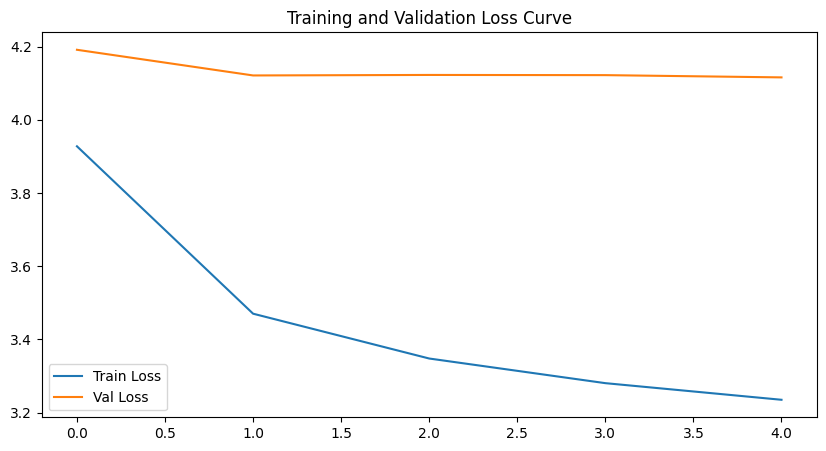

In [6]:
# Plot Loss Curves
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title("Training and Validation Loss Curve")
plt.legend()
plt.show()

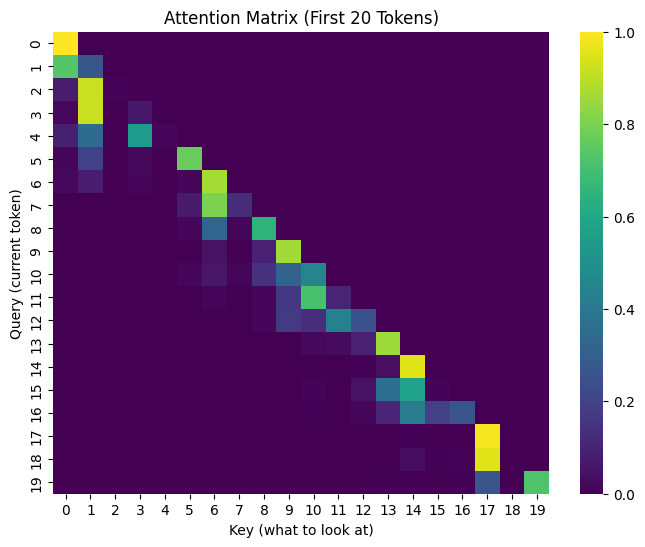

In [7]:
# Plot Attention Heatmap
with torch.no_grad():
    sample_x = torch.tensor([tokens[:seq_len]]).to(device)
    model(sample_x)
    # Get attention from the first block, first head
    attn = model.blocks[0]['attn'].attn_weights[0, 0].cpu().numpy()

plt.figure(figsize=(8,6))
sns.heatmap(attn[:20, :20], cmap='viridis', annot=False)
plt.title("Attention Matrix (First 20 Tokens)")
plt.xlabel("Key (what to look at)")
plt.ylabel("Query (current token)")
plt.show()

In [12]:
# Sample Generation
def generate(prompt, length=50):
    model.eval()
    ids = tokenizer.encode(prompt).ids
    input_t = torch.tensor([ids], device=device)
    for _ in range(length):
        with torch.no_grad():
            out = model(input_t[:, -seq_len:])
            next_id = torch.argmax(out[:, -1, :], dim=-1).unsqueeze(0)
            input_t = torch.cat([input_t, next_id], dim=1)
    return tokenizer.decode(input_t[0].tolist())

print("\n--- Generated Text ---")
print(generate("The King said", 100))


--- Generated Text ---
The K ing sa id , and I ' ll be ar my heart . C l own : I ' ll be ar my s oul , and I ' ll be ar the c rown , and I am not to be ar my s oul . C l own : I t is a ble , I ' ll not be ar my heart . C l own : I t is a ble , I ' ll not be ar my heart . C l own : I t is a ble , I ' ll not be ar my heart
